# Final Data Analysis Project


**Background**

background information

**Questions**
- Is there a meaningful hometeam advantage? 
- Are certain teams more likely to end a match in a shootout?
- Is there a relationship between the GDP of a country and the success of its national team?

# Importing Modules

In [173]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import math
import datetime
import sqlite3

# International Football Dataset

**Import Data**

In [274]:
import os

football = pd.read_csv("football_results.csv")
football.shape
#football.head()

gdp = pd.read_csv('gdp.csv')
gdp.head()

,country_name,Code,1960,1961,1962,1963,1964,1965,1966,1967,...,2012,2013,2014,2015,2016,2017,target_year,2019,2020,Unnamed: 65
0,Aruba,ABW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.534637e+09,2.727850e+09,2.790849e+09,2.962905e+09,2.983637e+09,3.092430e+09,3.202189e+09,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,1.931311e+10,1.972349e+10,2.149392e+10,2.573321e+10,2.352744e+10,2.681057e+10,2.915216e+10,3.017317e+10,...,9.505214e+11,9.642424e+11,9.848071e+11,9.199300e+11,8.733549e+11,9.853557e+11,1.012853e+12,1.009910e+12,9.207923e+11,NaN
2,Afghanistan,AFG,5.377778e+08,5.488889e+08,5.466667e+08,7.511112e+08,8.000000e+08,1.006667e+09,1.400000e+09,1.673333e+09,...,1.990732e+10,2.014640e+10,2.049713e+10,1.913421e+10,1.811656e+10,1.875347e+10,1.805323e+10,1.879945e+10,2.011614e+10,NaN
3,Africa Western and Central,AFW,1.040428e+10,1.112805e+10,1.194335e+10,1.267652e+10,1.383858e+10,1.486247e+10,1.583285e+10,1.442643e+10,...,7.275714e+11,8.207876e+11,8.649666e+11,7.607297e+11,6.905430e+11,6.837416e+11,7.416916e+11,7.945725e+11,7.845876e+11,NaN
4,Angola,AGO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.280529e+11,1.367099e+11,1.457122e+11,1.161936e+11,1.011239e+11,1.221238e+11,1.013532e+11,8.941719e+10,5.837598e+10,NaN


# Data Cleaning

**information

# Initial Data Assessment

In [175]:
total_teams = []
for i in football['home_team']:
    if i not in total_teams:
        total_teams.append(i)
for i in football['away_team']:
    if i not in total_teams:
        total_teams.append(i)
print(total_teams)
print(len(total_teams))

['Scotland', 'England', 'Wales', 'Northern Ireland', 'United States', 'Uruguay', 'Austria', 'Hungary', 'Argentina', 'Belgium', 'France', 'Netherlands', 'Czechoslovakia', 'Switzerland', 'Sweden', 'Germany', 'Italy', 'Chile', 'Norway', 'Finland', 'Luxembourg', 'Russia', 'Denmark', 'Catalonia', 'Basque Country', 'Brazil', 'Japan', 'Paraguay', 'Canada', 'Estonia', 'Costa Rica', 'Guatemala', 'Spain', 'Brittany', 'Poland', 'Yugoslavia', 'New Zealand', 'Romania', 'Latvia', 'Galicia', 'Portugal', 'Andalusia', 'China PR', 'Australia', 'Lithuania', 'Turkey', 'Central Spain', 'Mexico', 'Aruba', 'Egypt', 'Haiti', 'Philippines', 'Bulgaria', 'Jamaica', 'Kenya', 'Bolivia', 'Peru', 'Honduras', 'Guyana', 'Uganda', 'Belarus', 'El Salvador', 'Barbados', 'Republic of Ireland', 'Trinidad and Tobago', 'Greece', 'Curaçao', 'Dominica', 'Silesia', 'Guadeloupe', 'Israel', 'Suriname', 'French Guiana', 'Cuba', 'Colombia', 'Ecuador', 'Saint Kitts and Nevis', 'Panama', 'Slovakia', 'Manchukuo', 'Croatia', 'Nicaragua

All winners

In [176]:
reg_winners = []
for i in range(44060):
    if football['home_score'][i] > football['away_score'][i]:
        reg_winners.append(football['home_team'][i])
    if football['home_score'][i] < football['away_score'][i]:
        reg_winners.append(football['away_team'][i])
    if football['home_score'][i] == football['away_score'][i]:
        reg_winners.append('TIE')

   

    

In [177]:
football['total_score'] = football['home_score'] + football['away_score']
football['winner'] = reg_winners
football.head()  

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,knockout,total_score,winner,home_win
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False,False,0,TIE,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,False,6,England,True
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False,False,3,Scotland,True
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False,False,4,TIE,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False,False,3,Scotland,True


Average Score per Match

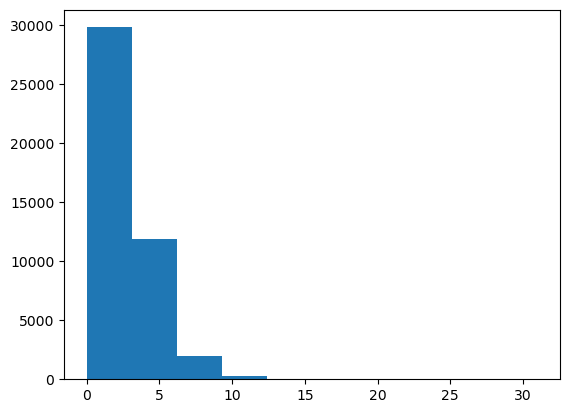

In [178]:
total_score = []
for i in range(44060):
    total_score.append(football['home_score'][i] + football['away_score'][i])
plt.hist(total_score)
plt.show()
                       

Goals per tournament

(array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
         13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
         26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
         39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
         52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
         65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
         78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
         91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
        104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
        117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
        130, 131, 132, 133, 134, 135, 136, 137, 138]),
 [Text(0, 0, 'ABCS Tournament'),
  Text(1, 0, 'AFC Asian Cup'),
  Text(2, 0, 'AFC Asian Cup qualification'),
  Text(3, 0, 'AFC Challenge Cup'),
  Text(4, 0, 'AFC Challenge Cup qualification'),
  Text(5, 0, 'AFF Cham

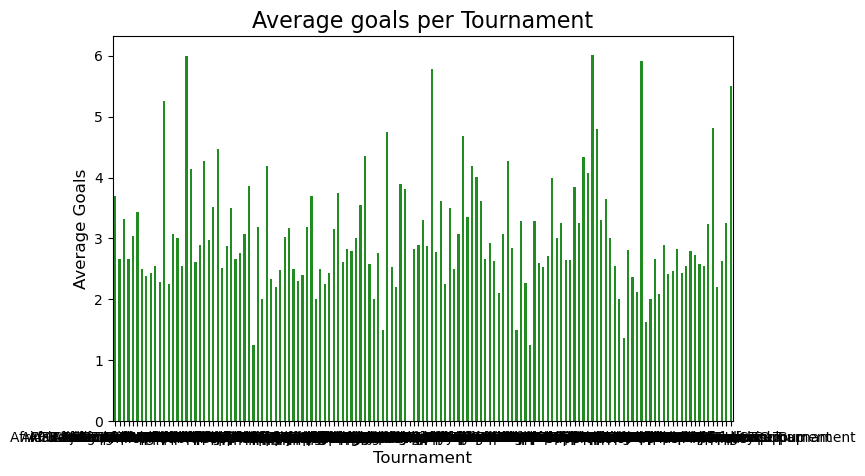

In [179]:
tournament_goals = football.groupby('tournament') ['total_score'].mean() #use groupby to get the number of units sold sorted by region
tournament_goals
tournament_goals.plot(kind = 'bar', color = 'forestgreen', figsize = (8,5)) #creates a bar chart and sets size and color
plt.title('Average goals per Tournament', fontsize = 16)
plt.xlabel('Tournament', fontsize = 12)
plt.ylabel('Average Goals', fontsize = 12)
plt.xticks(rotation = 0)

In [180]:
>>> df = pd.DataFrame(football )
>>> df.to_csv("football_results.csv", index=False)

In [181]:
football.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,knockout,total_score,winner,home_win
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False,False,0,TIE,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,False,6,England,True
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False,False,3,Scotland,True
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False,False,4,TIE,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False,False,3,Scotland,True


In [182]:
conn = sqlite3.connect(':memory:')
football.to_sql('football_sql', conn, index=False)

# average goals for just the FIFA World Cup
world_cup = pd.read_sql_query("""
    SELECT tournament, AVG(total_score) AS avg_goals
    FROM football_sql
    WHERE tournament = 'FIFA World Cup'
""", conn)
world_cup

,tournament,avg_goals
0,FIFA World Cup,2.831111


In [183]:
conn = sqlite3.connect(':memory:')
football.to_sql('football_sql', conn, index=False)

# average goals for just the UEFA Euro
uefa_euro = pd.read_sql_query("""
    SELECT tournament, AVG(total_score) AS avg_goals
    FROM football_sql
    WHERE tournament = 'UEFA Euro'
""", conn)
uefa_euro

,tournament,avg_goals
0,UEFA Euro,2.459941


In [184]:
conn = sqlite3.connect(':memory:')
football.to_sql('football_sql', conn, index=False)

# average goals for just the FIFA World Cup
afc_cup = pd.read_sql_query("""
    SELECT tournament, AVG(total_score) AS avg_goals
    FROM football_sql
    WHERE tournament = 'AFC Asian Cup'
""", conn)
afc_cup

,tournament,avg_goals
0,AFC Asian Cup,2.667568


In [185]:
conn = sqlite3.connect(':memory:')
football.to_sql('football_sql', conn, index=False)

# average goals for just the FIFA World Cup
african_cup = pd.read_sql_query("""
    SELECT tournament, AVG(total_score) AS avg_goals
    FROM football_sql
    WHERE tournament = 'African Cup of Nations'
""", conn)
african_cup

,tournament,avg_goals
0,African Cup of Nations,2.386792


In [186]:
conn = sqlite3.connect(':memory:')
football.to_sql('football_sql', conn, index=False)

# average goals for just the FIFA World Cup
concacaf = pd.read_sql_query("""
    SELECT tournament, AVG(total_score) AS avg_goals
    FROM football_sql
    WHERE tournament = 'CONCACAF Championship'
""", conn)
concacaf

,tournament,avg_goals
0,CONCACAF Championship,2.662722


In [187]:
conn = sqlite3.connect(':memory:')
football.to_sql('football_sql', conn, index=False)

# average goals for just the FIFA World Cup
conmebol = pd.read_sql_query("""
    SELECT tournament, AVG(total_score) AS avg_goals
    FROM football_sql
    WHERE tournament = 'CONMEBOL–UEFA Cup of Champions'
""", conn)
conmebol

,tournament,avg_goals
0,CONMEBOL–UEFA Cup of Champions,2.333333


In [188]:
conn = sqlite3.connect(':memory:')
football.to_sql('football_sql', conn, index=False)

# average goals for just the FIFA World Cup
oceania = pd.read_sql_query("""
    SELECT tournament, AVG(total_score) AS avg_goals
    FROM football_sql
    WHERE tournament = 'Oceania Nations Cup'
""", conn)
oceania

,tournament,avg_goals
0,Oceania Nations Cup,4.336634


In [189]:
conn = sqlite3.connect(':memory:')
football.to_sql('football_sql', conn, index=False)

# average goals for just the FIFA World Cup
gold = pd.read_sql_query("""
    SELECT tournament, AVG(total_score) AS avg_goals
    FROM football_sql
    WHERE tournament = 'Gold Cup'
""", conn)
gold

,tournament,avg_goals
0,Gold Cup,2.77095


In [190]:
#average_wins = pd.DataFrame([world_cup], [uefa_euro])
average_wins = pd.concat([world_cup, uefa_euro, oceania, conmebol, concacaf, afc_cup, african_cup, gold], ignore_index=True)
print(average_wins)
#average_wins.loc['world_cup'] = ['world_cup', world_cup['avg_goals'][0]]

                       tournament  avg_goals
0                  FIFA World Cup   2.831111
1                       UEFA Euro   2.459941
2             Oceania Nations Cup   4.336634
3  CONMEBOL–UEFA Cup of Champions   2.333333
4           CONCACAF Championship   2.662722
5                   AFC Asian Cup   2.667568
6          African Cup of Nations   2.386792
7                        Gold Cup   2.770950


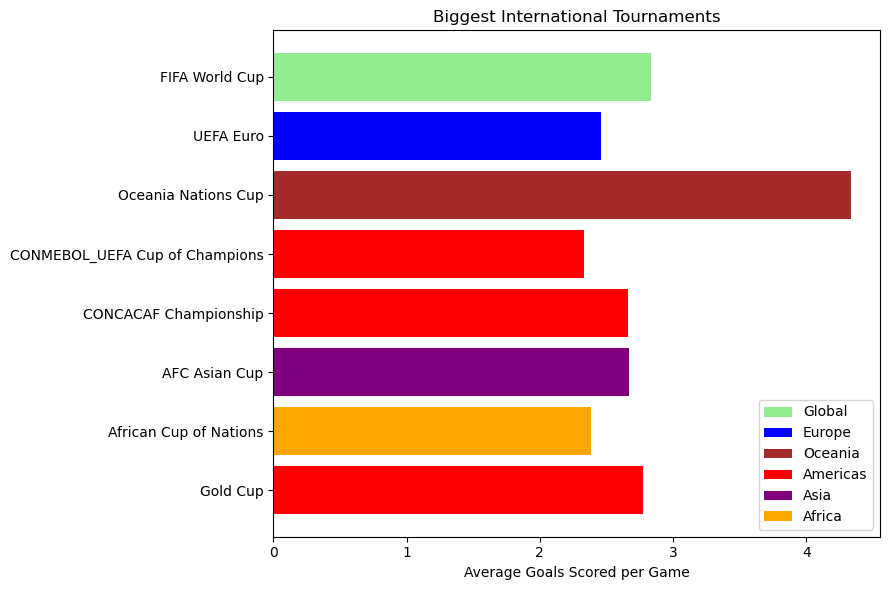

In [343]:
tournaments = ['FIFA World Cup', 'UEFA Euro', 'Oceania Nations Cup', 'CONMEBOL_UEFA Cup of Champions', 'CONCACAF Championship',
            'AFC Asian Cup', 'African Cup of Nations', 'Gold Cup']
av_goals = [2.831111, 2.459941, 4.336634, 2.333333, 2.662722, 2.667568, 2.386792, 2.770950]
categories = ['Global', 'Europe', 'Oceania', 'Americas', 'Americas',
              'Asia', 'Africa', 'Americas']

color_map = {'Global': 'lightgreen', 'Europe': 'blue',
             'Oceania': 'brown', 'Americas': 'red', 'Asia': 'purple', 'Africa': 'orange'}
colors = [color_map[c] for c in categories]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(tournaments[::-1], av_goals[::-1], color=colors[::-1])

ax.set_xlabel('Average Goals Scored per Game')
ax.set_title('Biggest International Tournaments')

# legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in color_map.items()]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('average_goals_figure')
plt.show()

Home advantage

In [192]:
home_wins = []
for i in range(44060):
    if football['neutral'][i] == False:
        if football['winner'][i] == football['home_team'][i]:
            home_wins.append(True)
        else:
            home_wins.append(False)
    else:
        home_wins.append(False)
        
#print(home_wins)

football['home_win'] = home_wins
football.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,knockout,total_score,winner,home_win
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False,False,0,TIE,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,False,6,England,True
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False,False,3,Scotland,True
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False,False,4,TIE,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False,False,3,Scotland,True


In [193]:
>>> df = pd.DataFrame(football )
>>> df.to_csv("football_results.csv", index=False)
football.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,knockout,total_score,winner,home_win
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False,False,0,TIE,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,False,6,England,True
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False,False,3,Scotland,True
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False,False,4,TIE,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False,False,3,Scotland,True


In [196]:
conn = sqlite3.connect(':memory:')
football.to_sql('football_sql', conn, index=False)

home_win_counts = pd.read_sql_query("""
    SELECT home_team, SUM(home_win) AS total_home_wins, COUNT(*) AS total_home_games 
    FROM football_sql
    WHERE neutral = 0
    GROUP BY home_team
    ORDER BY total_home_wins DESC
    LIMIT 20
""", conn)
home_win_counts

,home_team,total_home_wins,total_home_games
0,England,302,469
1,Sweden,277,464
2,Germany,272,433
3,France,262,447
4,Brazil,261,355
5,Italy,257,386
6,Hungary,249,441
7,United States,234,417
8,Netherlands,227,387
9,Spain,225,322


In [253]:
home_win_counts = pd.read_sql_query("""
    SELECT winner, COUNT(winner) AS wins, COUNT(away_team) AS total_away_games
    FROM football_sql
    WHERE neutral = 0
    GROUP BY winner
    ORDER BY wins DESC
    LIMIT 20
""", conn)
home_win_counts

,winner,wins,total_away_games
0,TIE,7657,7657
1,England,552,552
2,Germany,487,487
3,Sweden,472,472
4,Brazil,431,431
5,Hungary,423,423
6,France,387,387
7,Italy,383,383
8,Argentina,376,376
9,Scotland,374,374


In [ ]:
home_winners = pd.DataFrame(columns = ['team', 'home_wins'])
home_winners['team'] = total_teams
for i in range(316):
    for j in range(44060):
        if football['home_team'][j] == home_winners['team'][i]:
            if football['home_win'][j] == True:
                home_winners['home_wins'][i]+= 1



home_winners.head()

In [ ]:
conn = sqlite3.connect(':memory:')
football.to_sql('football_sql', conn, index=False)

home = pd.read_sql_query("""
    SELECT 
    FROM football_sql
    GROUP BY  """, conn)
home

Likelyhood of going to a shootout

In [220]:
shootout = pd.read_sql_query("""
    SELECT home_team, away_team, winner
    FROM football_sql
    WHERE knockout = True
""", conn)
shootout    

,home_team,away_team,winner
0,Germany,France,TIE
1,Poland,Italy,Italy
2,Poland,France,Poland
3,Italy,Germany,Italy
4,Mexico,Bulgaria,Mexico
...,...,...,...
135,Russia,Croatia,TIE
136,France,Belgium,France
137,Croatia,England,Croatia
138,Belgium,England,Belgium


In [219]:
teams = []
for i in range (140):
    if shootout['home_team'][i] not in teams:
        teams.append(shootout['home_team'][i])
    if shootout['away_team'][i] not in teams:
        teams.append(shootout['away_team'][i])
    
print(teams)

appearance = pd.DataFrame(teams)

counts = []
for j in range(45):
    count = 0
    for i in range(140):
        if shootout['home_team'][i] == teams[j]:
            count += 1
        if shootout['away_team'][i] == teams[j]:
            count += 1
    counts.append(count)
appearance['games'] = counts
appearance

['Germany', 'France', 'Poland', 'Italy', 'Mexico', 'Bulgaria', 'Russia', 'Belgium', 'Argentina', 'Uruguay', 'Brazil', 'Morocco', 'Denmark', 'Spain', 'England', 'Paraguay', 'Cameroon', 'Colombia', 'Czechoslovakia', 'Costa Rica', 'Netherlands', 'Republic of Ireland', 'Romania', 'Yugoslavia', 'Switzerland', 'Saudi Arabia', 'Sweden', 'United States', 'Nigeria', 'Chile', 'Norway', 'Serbia', 'Croatia', 'Senegal', 'Japan', 'Turkey', 'South Korea', 'Ecuador', 'Portugal', 'Australia', 'Ukraine', 'Ghana', 'Slovakia', 'Greece', 'Algeria']


,0,games
0,Germany,30
1,France,19
2,Poland,3
3,Italy,18
4,Mexico,8
5,Bulgaria,5
6,Russia,2
7,Belgium,12
8,Argentina,19
9,Uruguay,8


In [236]:
teams = []
for i in range (140):
    if shootout['home_team'][i] not in teams:
        if shootout['winner'][i] == 'TIE':
            teams.append(shootout['home_team'][i]) 
    if shootout['away_team'][i] not in teams:
        if shootout['winner'][i] == "TIE":
            teams.append(shootout['away_team'][i])
    
print(teams)


counts = []
for j in range(28):
    count = 0
    for i in range(140):
        if shootout['home_team'][i] == teams[j]:
            if shootout['winner'][i] == 'TIE':
                count += 1
        if shootout['away_team'][i] == teams[j]:
            if shootout['winner'][i] == 'TIE':
                count += 1
    counts.append(count)
appearance = pd.DataFrame({'Games':counts}, teams)

appearance

['Germany', 'France', 'Brazil', 'Mexico', 'Spain', 'Belgium', 'Republic of Ireland', 'Romania', 'Yugoslavia', 'Argentina', 'Italy', 'England', 'Bulgaria', 'Sweden', 'Netherlands', 'South Korea', 'Switzerland', 'Ukraine', 'Portugal', 'Paraguay', 'Japan', 'Uruguay', 'Ghana', 'Chile', 'Costa Rica', 'Greece', 'Russia', 'Croatia']


,Games
Germany,4
France,4
Brazil,4
Mexico,2
Spain,3
Belgium,1
Republic of Ireland,2
Romania,2
Yugoslavia,1
Argentina,5


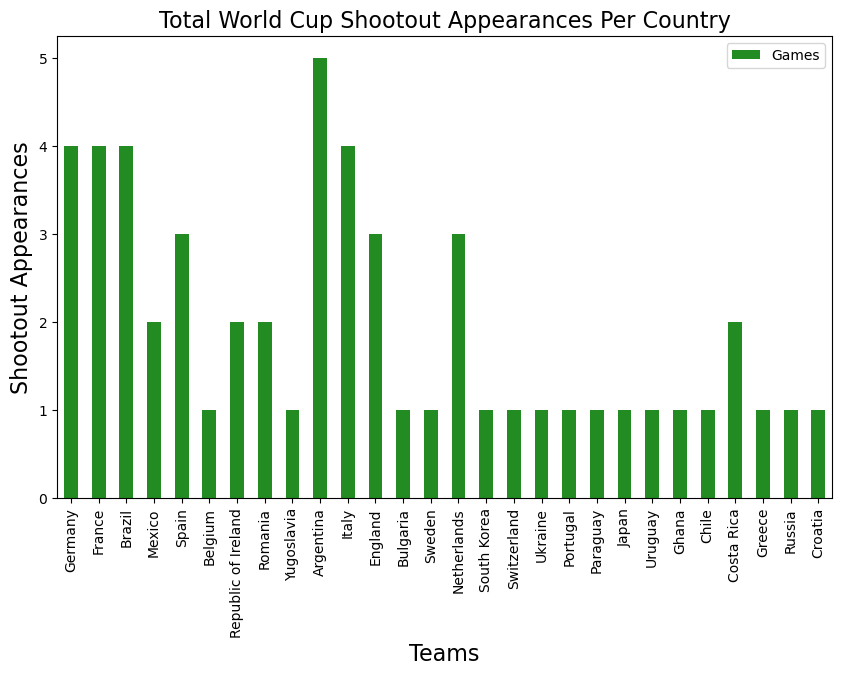

In [342]:
appearance.plot(kind = 'bar', color = 'forestgreen', figsize = (10,6))
plt.xlabel('Teams', fontsize = 16)
plt.ylabel('Shootout Appearances', fontsize = 16)
plt.title('Total World Cup Shootout Appearances Per Country', fontsize = 16)
plt.savefig('shootout_fig')
plt.show()

GDP success comparison

In [264]:
conn = sqlite3.connect(':memory:')
gdp.to_sql('gdp_sql', conn, index=False)
football.to_sql('football_sql', conn, index=False)

gdp_info = pd.read_sql_query("""
    SELECT country_name, target_year
    FROM gdp_sql
   
""", conn)
gdp_info  

,country_name,target_year
0,Aruba,3.202189e+09
1,Africa Eastern and Southern,1.012853e+12
2,Afghanistan,1.805323e+10
3,Africa Western and Central,7.416916e+11
4,Angola,1.013532e+11
...,...,...
261,Kosovo,7.878509e+09
262,"Yemen, Rep.",2.160614e+10
263,South Africa,4.048421e+11
264,Zambia,2.631159e+10


In [272]:
wc_2018 = pd.read_sql_query("""
    SELECT home_team, away_team, winner
    FROM football_sql
    WHERE tournament = 'FIFA World Cup' AND country = 'Russia'
   
""", conn)
wc_2018

,home_team,away_team,winner
0,Russia,Saudi Arabia,Russia
1,Egypt,Uruguay,Uruguay
2,Morocco,Iran,Iran
3,Portugal,Spain,TIE
4,France,Australia,France
...,...,...,...
59,Russia,Croatia,TIE
60,France,Belgium,France
61,Croatia,England,Croatia
62,Belgium,England,Belgium


In [286]:
gdp.set_index('country_name', inplace=True)
gdp.head()

,Code,1960,1961,1962,1963,1964,1965,1966,1967,1968,...,2012,2013,2014,2015,2016,2017,target_year,2019,2020,Unnamed: 65
country_name,,,,,,,,,,,,,,,,,,,,,
Aruba,ABW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.534637e+09,2.727850e+09,2.790849e+09,2.962905e+09,2.983637e+09,3.092430e+09,3.202189e+09,NaN,NaN,NaN
Africa Eastern and Southern,AFE,1.931311e+10,1.972349e+10,2.149392e+10,2.573321e+10,2.352744e+10,2.681057e+10,2.915216e+10,3.017317e+10,3.287706e+10,...,9.505214e+11,9.642424e+11,9.848071e+11,9.199300e+11,8.733549e+11,9.853557e+11,1.012853e+12,1.009910e+12,9.207923e+11,NaN
Afghanistan,AFG,5.377778e+08,5.488889e+08,5.466667e+08,7.511112e+08,8.000000e+08,1.006667e+09,1.400000e+09,1.673333e+09,1.373333e+09,...,1.990732e+10,2.014640e+10,2.049713e+10,1.913421e+10,1.811656e+10,1.875347e+10,1.805323e+10,1.879945e+10,2.011614e+10,NaN
Africa Western and Central,AFW,1.040428e+10,1.112805e+10,1.194335e+10,1.267652e+10,1.383858e+10,1.486247e+10,1.583285e+10,1.442643e+10,1.488035e+10,...,7.275714e+11,8.207876e+11,8.649666e+11,7.607297e+11,6.905430e+11,6.837416e+11,7.416916e+11,7.945725e+11,7.845876e+11,NaN
Angola,AGO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.280529e+11,1.367099e+11,1.457122e+11,1.161936e+11,1.011239e+11,1.221238e+11,1.013532e+11,8.941719e+10,5.837598e+10,NaN


In [331]:
wc_teams = []
for i in range (64):
    if wc_2018['home_team'][i] not in wc_teams:
        wc_teams.append(wc_2018['home_team'][i])
    if wc_2018['away_team'][i] not in wc_teams:
        wc_teams.append(wc_2018['away_team'][i])
    
print(wc_teams)
print(len(wc_teams))

gdp_2018 = []
for i in range (32):
    country = gdp.at[wc_teams[i], 'target_year']
    gdp_2018.append(country/1000000000000)
print(gdp_2018)

wc_gdp = pd.DataFrame({'Country': wc_teams, 'GDP': gdp_2018})
wc_gdp


['Russia', 'Saudi Arabia', 'Egypt', 'Uruguay', 'Morocco', 'Iran', 'Portugal', 'Spain', 'France', 'Australia', 'Argentina', 'Iceland', 'Peru', 'Denmark', 'Croatia', 'Nigeria', 'Costa Rica', 'Serbia', 'Germany', 'Mexico', 'Brazil', 'Switzerland', 'Sweden', 'South Korea', 'Belgium', 'Panama', 'Tunisia', 'England', 'Colombia', 'Japan', 'Poland', 'Senegal']
32
[np.float64(1.65732886571), np.float64(0.786521831573), np.float64(0.249712999437), np.float64(0.064515038268), np.float64(0.1180962274), np.float64(0.294356680625), np.float64(0.242194788534), np.float64(1.420300232664), np.float64(2.789593979065), np.float64(1.428529571351), np.float64(0.524819742919), np.float64(0.026267063758), np.float64(0.222574697256), np.float64(0.35684121641), np.float64(0.062247874949), np.float64(0.397190484464), np.float64(0.0624201651), np.float64(0.050640650221), np.float64(3.975347237443), np.float64(1.222408203104), np.float64(1.916933708382), np.float64(0.735539301553), np.float64(0.555455371487), np.

,Country,GDP
0,Russia,1.657329
1,Saudi Arabia,0.786522
2,Egypt,0.249713
3,Uruguay,0.064515
4,Morocco,0.118096
5,Iran,0.294357
6,Portugal,0.242195
7,Spain,1.420300
8,France,2.789594
9,Australia,1.428530


In [332]:
counter = []
for j in range(32):
    count = 0
    for i in range(64):
        if wc_2018['winner'][i] == wc_teams[j]:
            count += 1
    counter.append(count)

print(counter)

[2, 1, 0, 4, 0, 1, 1, 1, 6, 0, 1, 0, 1, 1, 4, 1, 0, 1, 1, 2, 3, 1, 3, 1, 6, 0, 1, 3, 2, 1, 1, 1]


In [333]:
wc_gdp['wins'] = counter
wc_gdp

,Country,GDP,wins
0,Russia,1.657329,2
1,Saudi Arabia,0.786522,1
2,Egypt,0.249713,0
3,Uruguay,0.064515,4
4,Morocco,0.118096,0
5,Iran,0.294357,1
6,Portugal,0.242195,1
7,Spain,1.420300,1
8,France,2.789594,6
9,Australia,1.428530,0


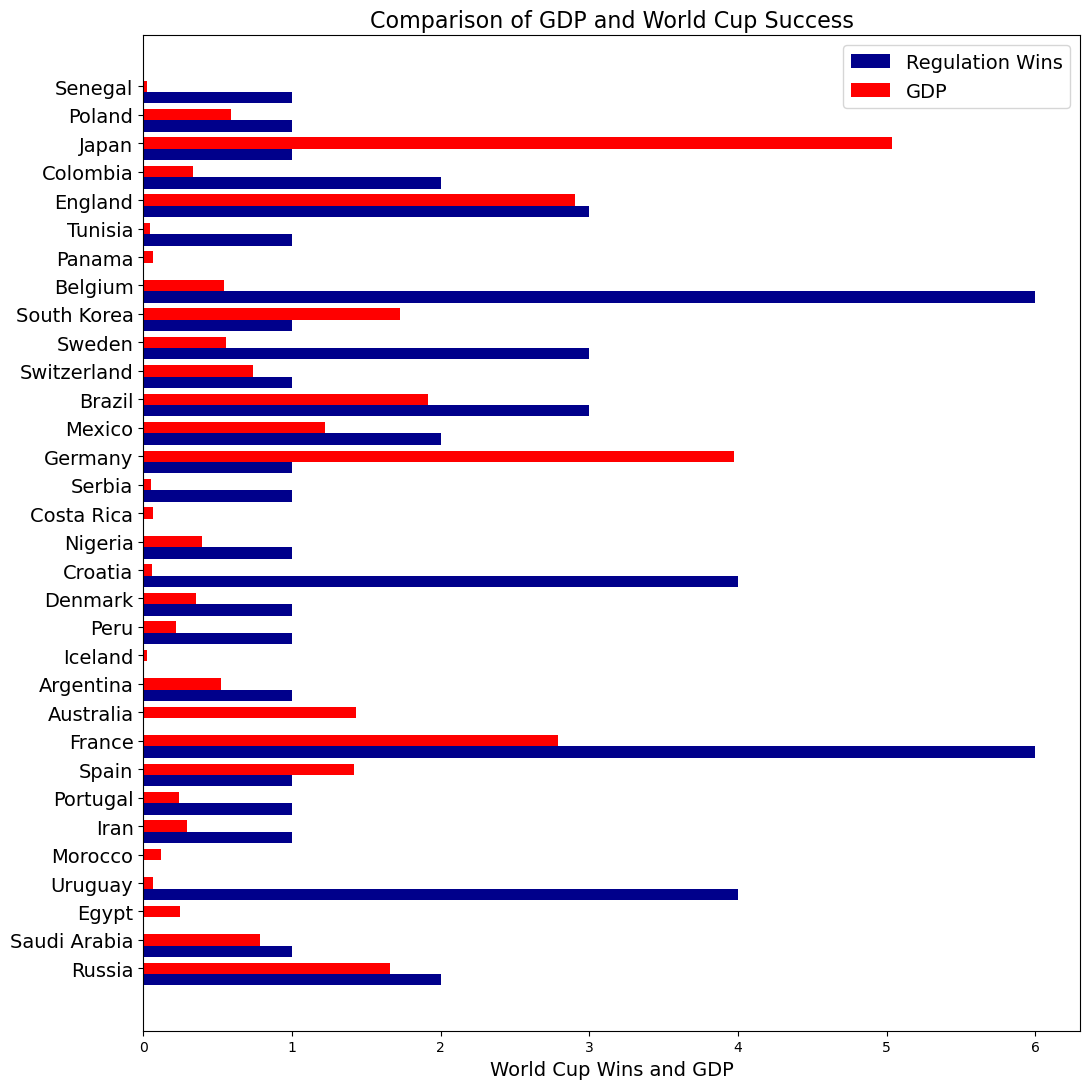

In [352]:
teams = wc_gdp['Country']
games_won = wc_gdp['wins']
country_gdp = wc_gdp['GDP']


x = np.arange(len(teams))
width = 0.4

fig, ax = plt.subplots(figsize=(11, 11))
ax.barh(x - width, games_won, width  , label='Regulation Wins', color='darkblue')
ax.barh(x , country_gdp, width , label='GDP', color='red')

ax.set_yticks(x)
ax.set_yticklabels(teams, fontsize = 14)
ax.set_xlabel('World Cup Wins and GDP', fontsize = 14)

ax.set_title('Comparison of GDP and World Cup Success', fontsize = 16)
ax.legend(fontsize = 14)
plt.tight_layout()
plt.savefig('gdp_wins')
plt.show()

# Conclusions

-Most of the tournaments have a similar number of goals scored per game, with the exception of the Oceania Nations Cup. 